In [15]:
import os
import json
import pandas as pd
import random
from task_clusterization.clusterization import save_cluster_model, classify_cluster

from pathlib import Path
from typing import List, Dict, Any

In [16]:
json_path = "/home/student/subin_workspace/2025DL-team-project/workspace/skeleton/task_clusterization/wrong_case.json"
path = Path(json_path)
data = json.loads(path.read_text(encoding='utf-8'))

tasks: List[Dict[str, Any]] = []
for item in data:
    # task id
    task_id = item.get("task")

    # train 예제들
    raw_train = item.get("train", [])
    train_list: List[Dict[str, List[List[int]]]] = []
    for ex in raw_train:
        train_list.append({
            "input":  ex.get("input", []),
            "output": ex.get("output", [])
        })

    # test-input, prediction
    test_inputs = item.get("test-input", [])
    preds       = item.get("prediction", [])

    tasks.append({
        "task":        task_id,
        "train":       train_list,
        "test-input":  test_inputs,
        "prediction":  preds
    })


In [22]:
model_dir = "/home/student/subin_workspace/2025DL-team-project/workspace/skeleton/artifacts/cluster_model"
wrong_num = len(tasks)
wrong_cluster = []
wrong_cluster_score = []
for i in range(wrong_num):
    s, score = classify_cluster(model_dir,tasks[i]['train'],print=False)
    wrong_cluster.append(s)
    wrong_cluster_score.append(score)
print(wrong_cluster)
print(wrong_cluster_score)

[np.int32(0), np.int32(2), np.int32(1), np.int32(3), np.int32(0), np.int32(5), np.int32(5), np.int32(5), np.int32(0), np.int32(0), np.int32(5), np.int32(0), np.int32(0), np.int32(0), np.int32(5), np.int32(0), np.int32(1), np.int32(5), np.int32(0), np.int32(0), np.int32(0), np.int32(0), np.int32(5), np.int32(0), np.int32(0), np.int32(1), np.int32(3), np.int32(0), np.int32(1), np.int32(2), np.int32(4), np.int32(0), np.int32(5), np.int32(0), np.int32(5), np.int32(5), np.int32(4), np.int32(5), np.int32(1), np.int32(0), np.int32(0), np.int32(5), np.int32(5), np.int32(3), np.int32(1), np.int32(0), np.int32(5), np.int32(5), np.int32(0), np.int32(5), np.int32(2), np.int32(0), np.int32(2), np.int32(2), np.int32(0), np.int32(5), np.int32(1), np.int32(0), np.int32(1), np.int32(0), np.int32(5), np.int32(3), np.int32(5), np.int32(0)]
[np.float64(0.83282632468627), np.float64(0.8170112687659792), np.float64(0.8784101126171483), np.float64(0.6702336328740827), np.float64(0.7676026364393823), np.float

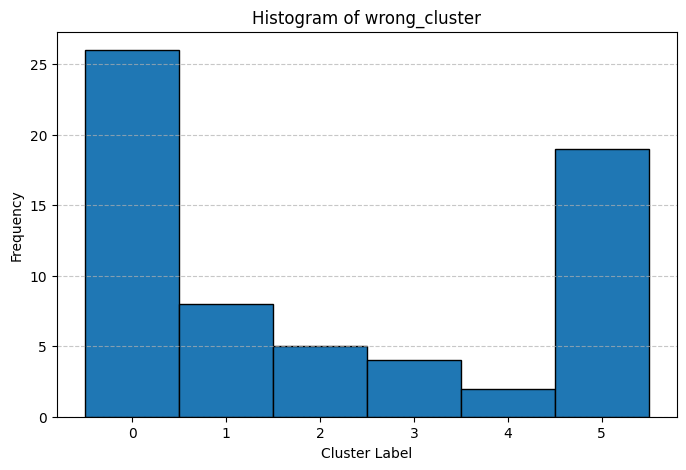

In [23]:
import matplotlib.pyplot as plt

# wrong_cluster: List[int] 형태 (예: [0, 2, 1, 0, 3, 2, ...])
# bins를 클러스터 번호별로 지정하고 싶다면 아래처럼 정의하세요:
min_label = min(wrong_cluster)
max_label = max(wrong_cluster)
bins = range(min_label, max_label + 2)  # +2인 이유는 마지막 라벨까지 포함시키기 위함

plt.figure(figsize=(8, 5))
plt.hist(wrong_cluster, bins=bins, edgecolor='black', align='left')
plt.xticks(range(min_label, max_label + 1))  # x축 눈금 설정
plt.xlabel('Cluster Label')
plt.ylabel('Frequency')
plt.title('Histogram of wrong_cluster')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

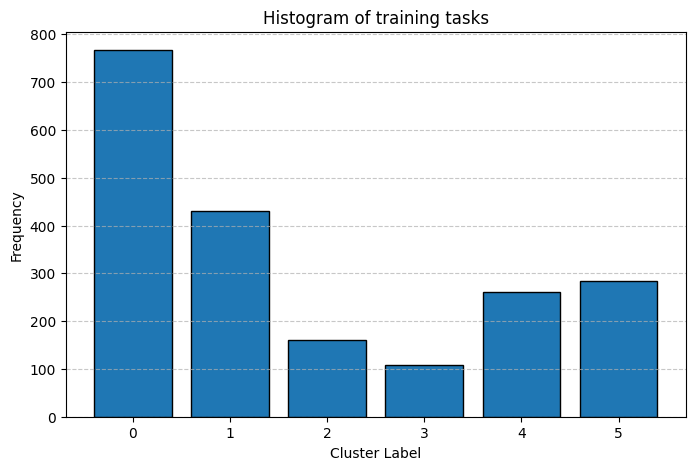

In [24]:
labels = [0, 1, 2, 3, 4, 5]
counts = [767,430,160,108,260,284]

plt.figure(figsize=(8, 5))
plt.bar(labels, counts, edgecolor='black')
plt.xticks(labels)
plt.xlabel('Cluster Label')
plt.ylabel('Frequency')
plt.title('Histogram of training tasks')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

In [39]:
counts_tot = [767,430,160,108,260,284]
counts_wrong = [0, 0, 0, 0, 0, 0]
ratio_task = [0, 0, 0, 0, 0, 0]
for i in range(len(wrong_cluster)):
    counts_wrong[wrong_cluster[i]] += 1
for i in range(len(counts_wrong)):
    ratio_task[i] = counts_wrong[i] *counts_tot[i]/counts_tot[i]
    #ratio_task[i]를 sqrt
    ratio_task[i] = ratio_task[i] ** 0.5
#ratio task 각 요소를 ratio task sum으로 나누기기
ratio_task_sum = sum(ratio_task)
for i in range(len(ratio_task)):
    ratio_task[i] = ratio_task[i] / ratio_task_sum*600
    #ratio_task[i]를 반올림
    ratio_task[i] = round(ratio_task[i])
print(ratio_task)

[171, 95, 75, 67, 47, 146]
